<a href="https://colab.research.google.com/github/bhavanivanapalli33/Visual-Cryptography-for-Phishing-Protection/blob/main/Enhancing_Online_Security_Using_Visual_Cryptography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

In [ ]:
# Upload Image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving Picture3.png to Picture3.png


In [ ]:
#load Original Image
original_image = cv2.imread(filename)

In [ ]:
#Convert BGR to RGB for Display in Matplotlib
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

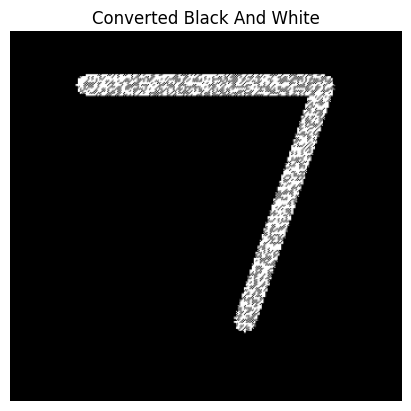

In [ ]:
#Dispaly the Original Image
plt.imshow(original_image_rgb)
plt.title('Converted Black And White')
plt.axis('off')
plt.show()

In [ ]:
# Load Image in Grayscale
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

In [ ]:
# Adaptive Thresholding for Binarization
binary_image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

rows, cols = binary_image.shape


In [ ]:
# Pixel Expansion Factor
expansion_factor = 2  # Using 2x2 expansion

In [ ]:
# Create Empty Shares
share1 = np.zeros((rows * expansion_factor, cols * expansion_factor), dtype=np.uint8)
share2 = np.zeros((rows * expansion_factor, cols * expansion_factor), dtype=np.uint8)


In [ ]:
# Define Fixed Patterns for 2x2 Expansion
white_pixel_patterns = [
    np.array([[255, 0], [0, 255]]),
    np.array([[0, 255], [255, 0]])
]

black_pixel_patterns = [
    np.array([[0, 255], [255, 0]]),
    np.array([[255, 0], [0, 255]])
]

In [ ]:
# Generate Shares
for i in range(rows):
    for j in range(cols):
        rand_index = np.random.randint(0, 2)
        if binary_image[i, j] == 255:  # White Pixel
            share1[i*expansion_factor:(i+1)*expansion_factor, j*expansion_factor:(j+1)*expansion_factor] = white_pixel_patterns[rand_index]
            share2[i*expansion_factor:(i+1)*expansion_factor, j*expansion_factor:(j+1)*expansion_factor] = white_pixel_patterns[rand_index]
        else:  # Black Pixel
            share1[i*expansion_factor:(i+1)*expansion_factor, j*expansion_factor:(j+1)*expansion_factor] = black_pixel_patterns[rand_index]
            share2[i*expansion_factor:(i+1)*expansion_factor, j*expansion_factor:(j+1)*expansion_factor] = black_pixel_patterns[1 - rand_index]  # Complement pattern


In [ ]:
# XOR-Based Reconstruction
reconstructed_image = np.bitwise_xor(share1, share2)

Binary Image


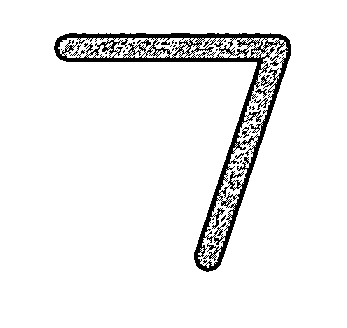

In [ ]:
# Display Results
print("Binary Image")
cv2_imshow(binary_image)


Share 1


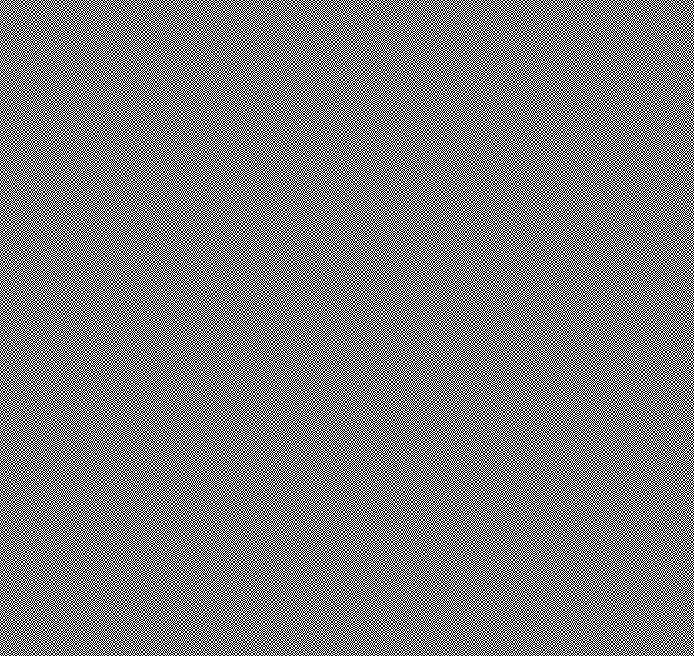

In [ ]:
print("Share 1")
cv2_imshow(share1)

Share 2


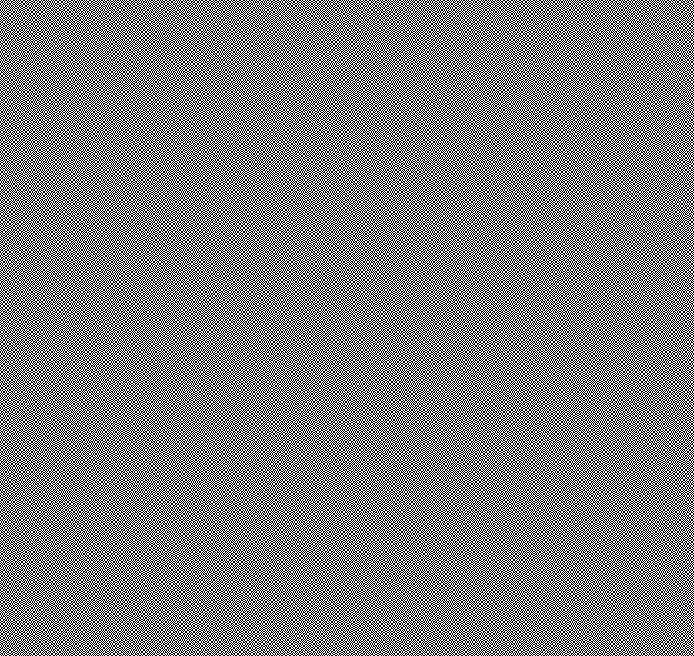

In [ ]:
print("Share 2")
cv2_imshow(share2)


Reconstructed Image


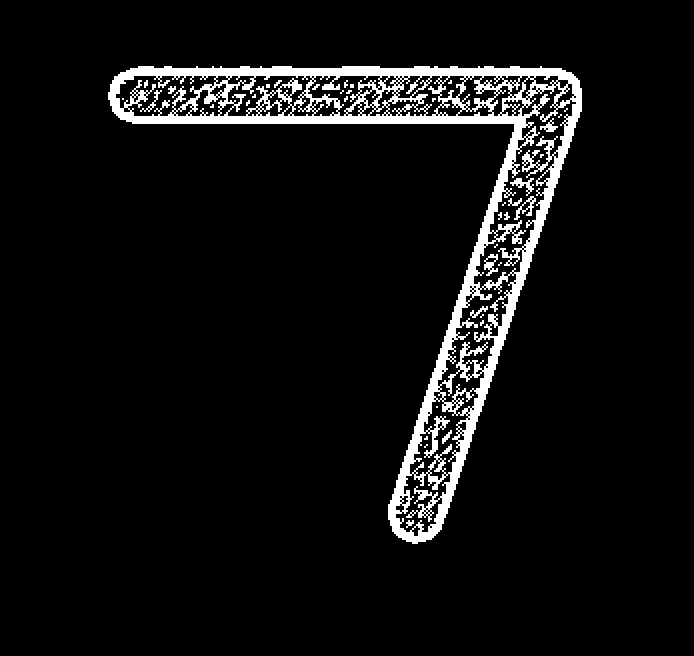

In [ ]:
print("Reconstructed Image")
cv2_imshow(reconstructed_image)